# Tối ưu baseline HOG + SVM cho phân loại nhóm biển báo giao thông trên GTSDB

## 1. Giới thiệu bài toán và giả thuyết

Bài toán của nhóm là phân loại nhóm biển báo giao thông trên bộ dữ liệu GTSDB. Đầu vào chính là các ROI biển báo được crop từ ground-truth bounding box. Đầu ra là nhóm biển báo, ví dụ prohibitory, danger, mandatory và other.

Baseline chính của bài là HOG + SVM mặc định. HOG được dùng để mô tả cấu trúc cạnh, đường viền và hướng gradient cục bộ của biển báo. SVM dùng vector đặc trưng HOG để phân loại nhóm biển báo.

Giả thuyết chính:
Từ baseline HOG + SVM mặc định, việc tối ưu các tham số của HOG như ROI size, pixels_per_cell, orientations, cells_per_block và preprocessing trước HOG có thể cải thiện Macro F1, vì các tham số này ảnh hưởng trực tiếp đến cách HOG biểu diễn chi tiết cạnh, viền và ký hiệu bên trong biển báo.

Thí nghiệm đối chứng phụ:
Bổ sung đặc trưng màu vào HOG được dùng như một đối chứng để kiểm tra liệu thông tin màu có bổ sung cho HOG hay không. Phần này không phải giả thuyết chính; nếu mức cải thiện nhỏ hoặc thấp hơn Optimized HOG, kết quả chỉ được dùng để tham khảo.

Phạm vi bài:
Bài chỉ đánh giá classification trên ROI crop từ ground-truth bounding box. Bài không xử lý việc tìm bounding box trên ảnh gốc.

Tiêu chí đánh giá chính:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Feature dimension
- Nhận xét trade-off giữa độ chính xác và độ phức tạp đặc trưng


## 2. Cơ sở nghiên cứu: HOG + SVM, GTSDB, preprocessing

HOG + SVM là một pipeline truyền thống trong nhận dạng/phát hiện đối tượng. HOG mô tả phân bố hướng gradient trong các cell cục bộ, sau đó các histogram được chuẩn hóa theo block để tạo vector đặc trưng. Vector này được đưa vào SVM để phân loại.

Với bài toán biển báo giao thông, HOG phù hợp vì biển báo có cấu trúc hình học rõ ràng như viền tròn, tam giác, chữ nhật, mũi tên, chữ số và biểu tượng bên trong.

Tuy nhiên, chất lượng HOG phụ thuộc vào:
- kích thước ROI;
- kích thước cell;
- số hướng gradient;
- số cell trong block;
- cách tiền xử lý ảnh trước khi tính gradient.

Vì vậy, các thí nghiệm trong bài không thử bừa mà được thiết kế theo mục đích xử lý ảnh: thay đổi cách biểu diễn gradient để tìm cấu hình phù hợp hơn cho biển báo.

Tài liệu tham khảo:

1. Dalal, N., & Triggs, B. (2005). *Histograms of Oriented Gradients for Human Detection*. IEEE Computer Society Conference on Computer Vision and Pattern Recognition (CVPR), 886–893.

2. Houben, S., Stallkamp, J., Salmen, J., Schlipsing, M., & Igel, C. (2013). *Detection of Traffic Signs in Real-World Images: The German Traffic Sign Detection Benchmark*. IEEE International Joint Conference on Neural Networks (IJCNN).

3. Vieira, L. A. (2025). *Comparing Performance of Preprocessing Techniques for Traffic Sign Recognition Using a HOG-SVM*. arXiv:2504.09424.

4. Temel, D., Chen, M.-H., & AlRegib, G. (2019). *Traffic Sign Detection under Challenging Conditions: A Deeper Look Into Performance Variations and Spectral Characteristics*. arXiv:1908.11262.


## 3. Load dataset và phân bố dữ liệu

Notebook yêu cầu GTSDB nằm trong `data/FullIJCNN2013/`. File `gt.txt` có dạng `filename;leftCol;topRow;rightCol;bottomRow;ClassID`. Các class chi tiết được gom thành bốn nhóm lớn để bài toán vừa đủ rõ ràng nhưng vẫn có ý nghĩa thực nghiệm.

Dữ liệu được chia theo ảnh gốc thay vì chia ngẫu nhiên từng crop. Cách này tránh trường hợp các crop từ cùng một ảnh xuất hiện đồng thời ở train và test, làm kết quả đánh giá bị lạc quan.


In [19]:
from pathlib import Path
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings("default")

DATA_ROOT = Path("data/FullIJCNN2013")
GT_PATH = DATA_ROOT / "gt.txt"

DATASET_HELP = """Bạn cần tải và giải nén GTSDB vào data/FullIJCNN2013/
Thư mục này phải có gt.txt và các ảnh 00000.ppm đến 00899.ppm."""

ppm_files = sorted(DATA_ROOT.glob("*.ppm")) if DATA_ROOT.exists() else []
if (not DATA_ROOT.exists()) or (not GT_PATH.exists()) or (len(ppm_files) == 0):
    print(DATASET_HELP)
    raise FileNotFoundError(DATASET_HELP)

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Số ảnh .ppm tìm thấy: {len(ppm_files)}")


Dataset root: C:\Users\ad\Downloads\codepython\Bai_Tap_ML\BTL_XLA\data\FullIJCNN2013
Số ảnh .ppm tìm thấy: 900


,filename,xmin,ymin,xmax,ymax,class_id,label_group
0,00000.ppm,774,411,815,446,11,danger
1,00001.ppm,983,388,1024,432,40,mandatory
2,00001.ppm,386,494,442,552,38,mandatory
3,00001.ppm,973,335,1031,390,13,other
4,00002.ppm,892,476,1006,592,39,mandatory


,số ảnh .ppm,số ảnh có annotation,số annotation,số biển báo
0,900,741,1213,1213


,count
label_group,
prohibitory,557
danger,219
mandatory,163
other,274


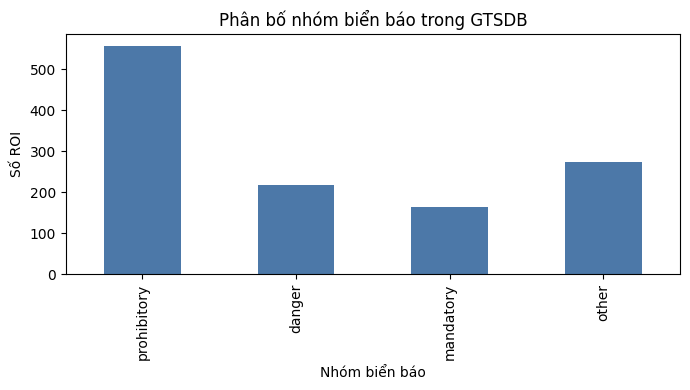

In [20]:
PROHIBITORY = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 15, 16]
DANGER = [11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
MANDATORY = [33, 34, 35, 36, 37, 38, 39, 40]
OTHER = [6, 12, 13, 14, 17, 32, 41, 42]
GROUP_ORDER = ["prohibitory", "danger", "mandatory", "other"]


def map_class_group(class_id):
    class_id = int(class_id)
    if class_id in PROHIBITORY:
        return "prohibitory"
    if class_id in DANGER:
        return "danger"
    if class_id in MANDATORY:
        return "mandatory"
    if class_id in OTHER:
        return "other"
    return "unknown"


def load_gtsdb_annotations(gt_path):
    columns = ["filename", "xmin", "ymin", "xmax", "ymax", "class_id"]
    df = pd.read_csv(gt_path, sep=";", names=columns)
    df[["xmin", "ymin", "xmax", "ymax", "class_id"]] = df[["xmin", "ymin", "xmax", "ymax", "class_id"]].astype(int)
    df["label_group"] = df["class_id"].apply(map_class_group)
    unknown = sorted(df.loc[df["label_group"] == "unknown", "class_id"].unique())
    if unknown:
        raise ValueError(f"Có ClassID chưa được map nhóm: {unknown}")
    return df


df = load_gtsdb_annotations(GT_PATH)
display(df.head())

summary = pd.DataFrame([{
    "số ảnh .ppm": len(ppm_files),
    "số ảnh có annotation": df["filename"].nunique(),
    "số annotation": len(df),
    "số biển báo": len(df),
}])
display(summary)

class_distribution = df["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0).to_frame("count")
display(class_distribution)

ax = class_distribution.plot(kind="bar", figsize=(7, 4), color="#4C78A8", legend=False)
ax.set_title("Phân bố nhóm biển báo trong GTSDB")
ax.set_xlabel("Nhóm biển báo")
ax.set_ylabel("Số ROI")
plt.tight_layout()
plt.show()


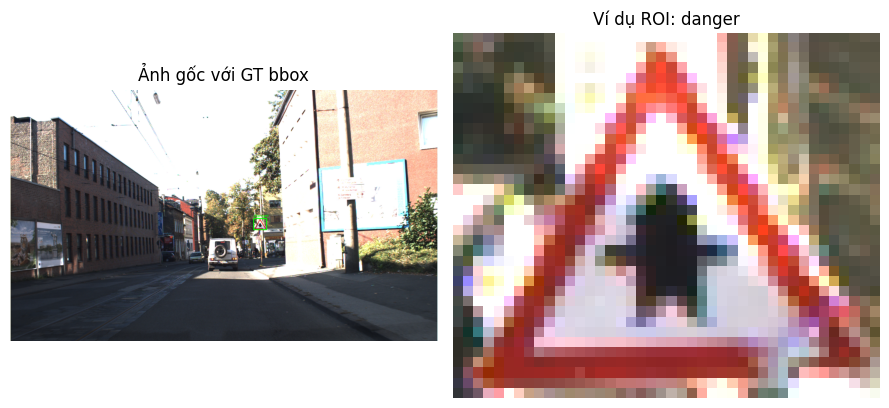

In [21]:
def read_image(path):
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def clip_box(box, width, height):
    xmin, ymin, xmax, ymax = [int(round(v)) for v in box]
    xmin = max(0, min(xmin, width - 1))
    ymin = max(0, min(ymin, height - 1))
    xmax = max(0, min(xmax, width - 1))
    ymax = max(0, min(ymax, height - 1))
    if xmax < xmin:
        xmin, xmax = xmax, xmin
    if ymax < ymin:
        ymin, ymax = ymax, ymin
    return xmin, ymin, xmax, ymax


def crop_box(image, box):
    h, w = image.shape[:2]
    xmin, ymin, xmax, ymax = clip_box(box, w, h)
    return image[ymin:ymax + 1, xmin:xmax + 1]


def draw_boxes(image, boxes, labels=None, color=(0, 255, 0), thickness=2):
    out = image.copy()
    labels = labels if labels is not None else [None] * len(boxes)
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if label:
            cv2.putText(out, str(label), (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return out


sample_file = df["filename"].drop_duplicates().iloc[0]
sample_image = read_image(DATA_ROOT / sample_file)
sample_rows = df[df["filename"] == sample_file]
sample_boxes = sample_rows[["xmin", "ymin", "xmax", "ymax"]].values.tolist()
sample_labels = sample_rows["label_group"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(draw_boxes(sample_image, sample_boxes, sample_labels))
axes[0].set_title("Ảnh gốc với GT bbox")
axes[0].axis("off")
sample_crop = crop_box(sample_image, sample_boxes[0])
axes[1].imshow(sample_crop)
axes[1].set_title(f"Ví dụ ROI: {sample_labels[0]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [22]:
def make_filename_split(df, test_size=0.25, random_state=RANDOM_STATE):
    file_df = df[["filename"]].drop_duplicates().reset_index(drop=True)
    filenames = file_df["filename"].to_numpy()
    file_labels = df.groupby("filename")["label_group"].agg(lambda s: s.value_counts().idxmax()).reindex(filenames).to_numpy()
    splitter = GroupShuffleSplit(n_splits=50, test_size=test_size, random_state=random_state)
    all_labels = set(df["label_group"].unique())
    for train_file_idx, test_file_idx in splitter.split(filenames, file_labels, groups=filenames):
        train_files = set(filenames[train_file_idx])
        test_files = set(filenames[test_file_idx])
        train_labels = set(df[df["filename"].isin(train_files)]["label_group"].unique())
        test_labels = set(df[df["filename"].isin(test_files)]["label_group"].unique())
        if train_labels == all_labels and test_labels == all_labels:
            return train_files, test_files
    raise ValueError("Không tạo được filename split có đủ lớp trong train/test.")


train_files, test_files = make_filename_split(df)
print(f"Số file train: {len(train_files)}")
print(f"Số file test: {len(test_files)}")

split_distribution = pd.DataFrame({
    "train": df[df["filename"].isin(train_files)]["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0),
    "test": df[df["filename"].isin(test_files)]["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0),
})
display(split_distribution)


Số file train: 555
Số file test: 186


,train,test
label_group,,
prohibitory,416,141
danger,153,66
mandatory,130,33
other,208,66


## 4. Feature extraction: HOG + preprocessing

Các hàm dưới đây chỉ phục vụ bài toán classification trên ROI crop từ ground-truth bounding box. Preprocessing hỗ trợ `gray`, `gray_clahe`, `gray_clahe_blur`, `yuv_y` và `hsv_v`. Color histogram chỉ được dùng cho thí nghiệm phụ `Color + HOG + SVM`.


In [23]:
DEFAULT_HOG_CONFIG = {
    "image_size": (64, 64),
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
    "preprocessing": "gray_clahe",
}


def normalize_tuple(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, str):
        cleaned = value.strip().strip("()")
        parts = [p.strip() for p in cleaned.split(",") if p.strip()]
        return tuple(int(p) for p in parts)
    return value


def make_hog_config(**updates):
    config = DEFAULT_HOG_CONFIG.copy()
    config.update(updates)
    config["image_size"] = normalize_tuple(config["image_size"])
    config["pixels_per_cell"] = normalize_tuple(config["pixels_per_cell"])
    config["cells_per_block"] = normalize_tuple(config["cells_per_block"])
    return config


def config_key(config, include_color=False):
    return (
        normalize_tuple(config["image_size"]),
        int(config["orientations"]),
        normalize_tuple(config["pixels_per_cell"]),
        normalize_tuple(config["cells_per_block"]),
        config["block_norm"],
        config["preprocessing"],
        include_color,
    )


def preprocess_for_hog(image_rgb, image_size=(64, 64), preprocessing="gray_clahe"):
    resized = cv2.resize(image_rgb, image_size, interpolation=cv2.INTER_AREA)
    if preprocessing == "gray":
        return cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    if preprocessing == "gray_clahe":
        gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(gray)
    if preprocessing == "gray_clahe_blur":
        gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        return cv2.GaussianBlur(enhanced, (3, 3), 0)
    if preprocessing == "yuv_y":
        return cv2.cvtColor(resized, cv2.COLOR_RGB2YUV)[:, :, 0]
    if preprocessing == "hsv_v":
        return cv2.cvtColor(resized, cv2.COLOR_RGB2HSV)[:, :, 2]
    raise ValueError(f"Không hỗ trợ preprocessing: {preprocessing}")


def extract_hog_feature(image_rgb, config):
    hog_input = preprocess_for_hog(
        image_rgb,
        image_size=normalize_tuple(config["image_size"]),
        preprocessing=config["preprocessing"],
    )
    return hog(
        hog_input,
        orientations=int(config["orientations"]),
        pixels_per_cell=normalize_tuple(config["pixels_per_cell"]),
        cells_per_block=normalize_tuple(config["cells_per_block"]),
        block_norm=config["block_norm"],
        visualize=False,
        feature_vector=True,
    ).astype(np.float32)


def color_hist_feature(image_rgb, image_size=(64, 64), bins=16):
    resized = cv2.resize(image_rgb, image_size, interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(resized, cv2.COLOR_RGB2HSV)
    feats = []
    for ch, rg in enumerate([(0, 180), (0, 256), (0, 256)]):
        hist = cv2.calcHist([hsv], [ch], None, [bins], rg).ravel().astype(np.float32)
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)


def extract_feature_from_crop(crop_rgb, config, include_color=False, color_bins=16):
    hog_feat = extract_hog_feature(crop_rgb, config)
    if include_color:
        color_feat = color_hist_feature(crop_rgb, image_size=normalize_tuple(config["image_size"]), bins=color_bins)
        return np.concatenate([hog_feat, color_feat]).astype(np.float32)
    return hog_feat


In [24]:
def make_linear_svc(C=1.0):
    try:
        return LinearSVC(C=C, random_state=RANDOM_STATE, max_iter=30000, dual="auto")
    except TypeError:
        return LinearSVC(C=C, random_state=RANDOM_STATE, max_iter=30000)


FEATURE_CACHE = {}


def build_feature_dataset(df_all, image_dir, config, include_color=False, color_bins=16):
    key = (config_key(config, include_color=include_color), color_bins)
    if key in FEATURE_CACHE:
        return FEATURE_CACHE[key]
    X, y, filenames = [], [], []
    for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Extract ROI features"):
        image = read_image(image_dir / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if crop.size == 0:
            continue
        feat = extract_feature_from_crop(crop, config, include_color=include_color, color_bins=color_bins)
        X.append(feat)
        y.append(row["label_group"])
        filenames.append(row["filename"])
    result = (np.vstack(X), np.array(y), np.array(filenames))
    FEATURE_CACHE[key] = result
    return result


def evaluate_hog_svm_config(model, role, config, include_color=False, color_bins=16, C=1.0):
    X, y, filenames = build_feature_dataset(df, DATA_ROOT, config, include_color=include_color, color_bins=color_bins)
    train_mask = np.isin(filenames, list(train_files))
    test_mask = np.isin(filenames, list(test_files))
    clf = Pipeline([("scaler", StandardScaler()), ("model", make_linear_svc(C=C))])
    clf.fit(X[train_mask], y[train_mask])
    y_pred = clf.predict(X[test_mask])
    precision, recall, f1, _ = precision_recall_fscore_support(y[test_mask], y_pred, average="macro", zero_division=0)
    return {
        "model": model,
        "role": role,
        "image_size": normalize_tuple(config["image_size"]),
        "orientations": int(config["orientations"]),
        "pixels_per_cell": normalize_tuple(config["pixels_per_cell"]),
        "cells_per_block": normalize_tuple(config["cells_per_block"]),
        "block_norm": config["block_norm"],
        "preprocessing": config["preprocessing"],
        "accuracy": accuracy_score(y[test_mask], y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "feature_dim": X.shape[1],
        "classifier": clf,
        "y_test": y[test_mask],
        "y_pred": y_pred,
    }


def result_table(results):
    cols = [
        "model", "role", "image_size", "orientations", "pixels_per_cell", "cells_per_block",
        "block_norm", "preprocessing", "accuracy", "macro_precision", "macro_recall", "macro_f1", "feature_dim",
    ]
    return pd.DataFrame([{k: r[k] for k in cols} for r in results])


def plot_macro_f1(df_result, x_col, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(df_result[x_col].astype(str), df_result["macro_f1"], color="#59A14F")
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Macro F1")
    ax.tick_params(axis="x", rotation=20)
    for idx, value in enumerate(df_result["macro_f1"]):
        ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


## 5. Baseline HOG + SVM mặc định

Baseline chính dùng `DEFAULT_HOG_CONFIG` và Linear SVM. Đây là mốc so sánh cho toàn bộ các sweep sau.


Extract ROI features: 100%|██████████| 1213/1213 [00:22<00:00, 54.61it/s]


,model,role,accuracy,macro_precision,macro_recall,macro_f1,feature_dim
0,Baseline HOG + SVM,baseline chính,0.980392,0.978883,0.962121,0.969951,1764


Baseline HOG + SVM mặc định đạt Macro F1 = 0.9700.


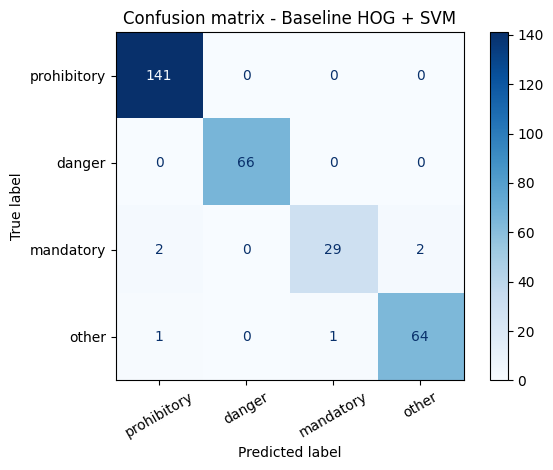

In [25]:
baseline_result = evaluate_hog_svm_config(
    model="Baseline HOG + SVM",
    role="baseline chính",
    config=DEFAULT_HOG_CONFIG,
    include_color=False,
)
baseline_table = result_table([baseline_result])
display(baseline_table[["model", "role", "accuracy", "macro_precision", "macro_recall", "macro_f1", "feature_dim"]])
baseline_macro_f1 = baseline_result["macro_f1"]
print(f"Baseline HOG + SVM mặc định đạt Macro F1 = {baseline_macro_f1:.4f}.")

cm = confusion_matrix(baseline_result["y_test"], baseline_result["y_pred"], labels=GROUP_ORDER)
ConfusionMatrixDisplay(cm, display_labels=GROUP_ORDER).plot(cmap="Blues", xticks_rotation=30)
plt.title("Confusion matrix - Baseline HOG + SVM")
plt.tight_layout()
plt.show()


## 6. Thiết kế cấu hình HOG tối ưu để kiểm tra giả thuyết chính

Các sweep dưới đây không phải là giả thuyết chính riêng lẻ. Chúng dùng để xác định cấu hình HOG phù hợp nhất. Sau khi chọn được cấu hình tốt nhất, notebook sẽ dùng cấu hình đó trong thí nghiệm chính để kiểm tra giả thuyết: tối ưu cấu hình HOG có cải thiện Macro F1 so với baseline HOG + SVM mặc định hay không.

### 6.1 ROI size

ROI size ảnh hưởng đến lượng chi tiết được giữ lại trước khi tính HOG. ROI quá nhỏ có thể làm mất chi tiết ký hiệu bên trong biển báo, trong khi ROI quá lớn làm vector đặc trưng dài hơn và có thể tăng nhiễu.


Extract ROI features: 100%|██████████| 1213/1213 [00:09<00:00, 128.00it/s]


,image_size,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(32, 32)",0.912068,324,0.934641,0.930379,0.898211
1,"(64, 64)",0.969951,1764,0.980392,0.978883,0.962121
2,"(96, 96)",0.974813,4356,0.980392,0.972167,0.977756


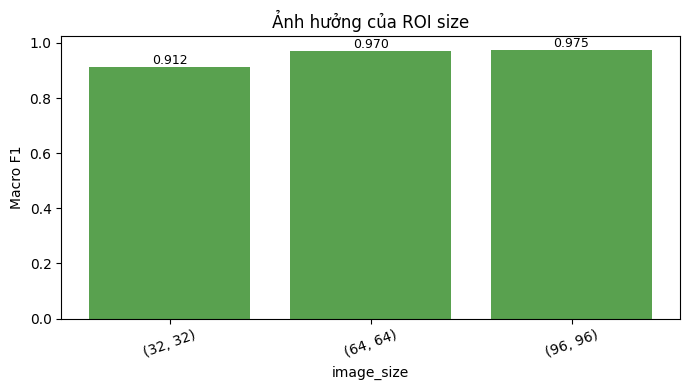

ROI size tốt nhất là (96, 96) với Macro F1 = 0.9748.


In [26]:
roi_results = []
for size in [(32, 32), (64, 64), (96, 96)]:
    config = make_hog_config(image_size=size)
    roi_results.append(evaluate_hog_svm_config("HOG + SVM", "ROI size sweep", config))
roi_sweep = result_table(roi_results)
display(roi_sweep[["image_size", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(roi_sweep, "image_size", "Ảnh hưởng của ROI size")
best_roi = roi_sweep.sort_values("macro_f1", ascending=False).iloc[0]
print(f"ROI size tốt nhất là {best_roi['image_size']} với Macro F1 = {best_roi['macro_f1']:.4f}.")


### 6.2 pixels_per_cell

pixels_per_cell quyết định độ chi tiết của HOG. Cell nhỏ giúp bắt chi tiết nhỏ như số, mũi tên và viền biển báo, nhưng có thể làm feature dài và nhạy với nhiễu. Cell lớn mô tả thô hơn, ít nhiễu hơn nhưng có thể bỏ mất chi tiết.


Extract ROI features: 100%|██████████| 1213/1213 [00:07<00:00, 171.20it/s]


,pixels_per_cell,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(4, 4)",0.972417,8100,0.983660,0.973346,0.971712
1,"(8, 8)",0.969951,1764,0.980392,0.978883,0.962121
2,"(16, 16)",0.966443,324,0.973856,0.975410,0.958575


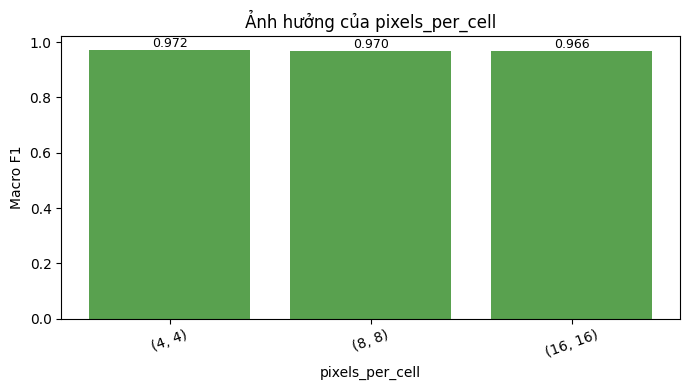

pixels_per_cell tốt nhất là (4, 4) với Macro F1 = 0.9724.


In [27]:
ppc_results = []
for ppc in [(4, 4), (8, 8), (16, 16)]:
    config = make_hog_config(pixels_per_cell=ppc)
    ppc_results.append(evaluate_hog_svm_config("HOG + SVM", "pixels_per_cell sweep", config))
ppc_sweep = result_table(ppc_results)
display(ppc_sweep[["pixels_per_cell", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(ppc_sweep, "pixels_per_cell", "Ảnh hưởng của pixels_per_cell")
best_ppc = ppc_sweep.sort_values("macro_f1", ascending=False).iloc[0]
print(f"pixels_per_cell tốt nhất là {best_ppc['pixels_per_cell']} với Macro F1 = {best_ppc['macro_f1']:.4f}.")


### 6.3 orientations

orientations là số bin hướng gradient. Số bin ít làm đặc trưng gọn và ổn định hơn, nhưng mô tả hướng cạnh thô hơn. Số bin nhiều mô tả hướng cạnh chi tiết hơn, nhưng có thể làm histogram thưa và nhạy với nhiễu.


Extract ROI features: 100%|██████████| 1213/1213 [00:06<00:00, 174.57it/s]


,orientations,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,6,0.980696,1176,0.986928,0.989041,0.973485
1,9,0.969951,1764,0.980392,0.978883,0.962121
2,12,0.967825,2352,0.977124,0.969635,0.966151


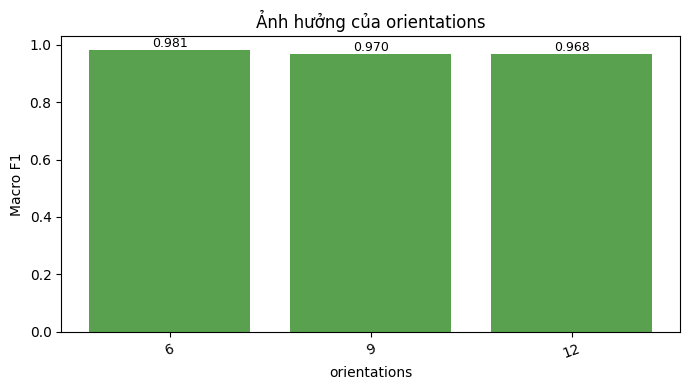

orientations tốt nhất là 6 với Macro F1 = 0.9807.
Không phải cứ tăng số hướng gradient là tốt. Với dữ liệu hiện tại, số hướng ít hơn có thể giúp vector HOG ổn định hơn.


In [28]:
orientation_results = []
for orientations in [6, 9, 12]:
    config = make_hog_config(orientations=orientations)
    orientation_results.append(evaluate_hog_svm_config("HOG + SVM", "orientations sweep", config))
orientation_sweep = result_table(orientation_results)
display(orientation_sweep[["orientations", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(orientation_sweep, "orientations", "Ảnh hưởng của orientations")
best_orientation = orientation_sweep.sort_values("macro_f1", ascending=False).iloc[0]
print(f"orientations tốt nhất là {best_orientation['orientations']} với Macro F1 = {best_orientation['macro_f1']:.4f}.")
if int(best_orientation["orientations"]) == 6:
    print("Không phải cứ tăng số hướng gradient là tốt. Với dữ liệu hiện tại, số hướng ít hơn có thể giúp vector HOG ổn định hơn.")


### 6.4 cells_per_block

cells_per_block ảnh hưởng đến cách chuẩn hóa cục bộ của HOG. Block lớn hơn có thể giúp đặc trưng ổn định hơn với thay đổi sáng/tối, nhưng cũng làm feature dài hơn.


Extract ROI features: 100%|██████████| 1213/1213 [00:09<00:00, 126.96it/s]


,cells_per_block,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(1, 1)",0.965205,576,0.977124,0.964293,0.966151
1,"(2, 2)",0.969951,1764,0.980392,0.978883,0.962121
2,"(3, 3)",0.975039,2916,0.983660,0.980863,0.969697


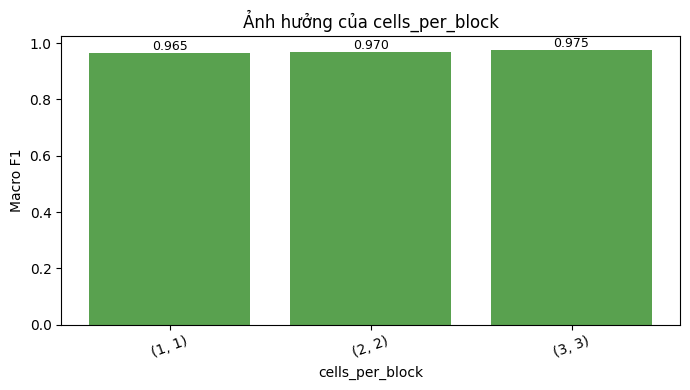

cells_per_block tốt nhất là (3, 3) với Macro F1 = 0.9750.


In [29]:
cpb_results = []
for cpb in [(1, 1), (2, 2), (3, 3)]:
    config = make_hog_config(cells_per_block=cpb)
    cpb_results.append(evaluate_hog_svm_config("HOG + SVM", "cells_per_block sweep", config))
cpb_sweep = result_table(cpb_results)
display(cpb_sweep[["cells_per_block", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(cpb_sweep, "cells_per_block", "Ảnh hưởng của cells_per_block")
best_cpb = cpb_sweep.sort_values("macro_f1", ascending=False).iloc[0]
print(f"cells_per_block tốt nhất là {best_cpb['cells_per_block']} với Macro F1 = {best_cpb['macro_f1']:.4f}.")


### 6.5 preprocessing trước HOG

Preprocessing ảnh hưởng đến gradient đầu vào của HOG. CLAHE có thể tăng tương phản cục bộ, blur có thể giảm nhiễu, YUV-Y và HSV-V tách thông tin độ sáng khỏi màu để kiểm tra xem kênh sáng nào tạo gradient tốt hơn.


Extract ROI features: 100%|██████████| 1213/1213 [00:09<00:00, 127.58it/s]


,preprocessing,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,gray,0.960513,1764,0.973856,0.967119,0.954545
1,gray_clahe,0.969951,1764,0.980392,0.978883,0.962121
2,gray_clahe_blur,0.970444,1764,0.980392,0.975435,0.965909
3,yuv_y,0.960513,1764,0.973856,0.967119,0.954545
4,hsv_v,0.979288,1764,0.986928,0.979288,0.979288


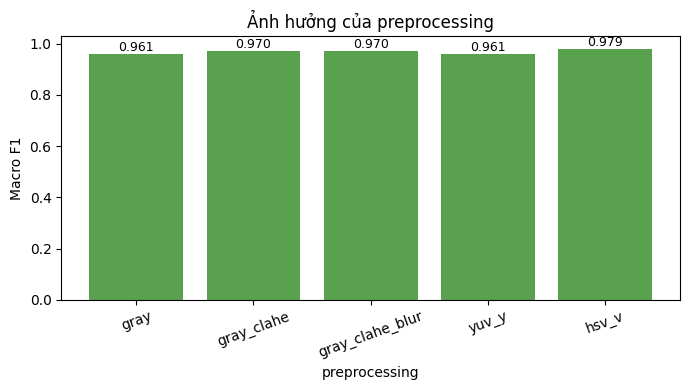

preprocessing tốt nhất là hsv_v với Macro F1 = 0.9793.


In [30]:
preprocessing_results = []
for preprocessing in ["gray", "gray_clahe", "gray_clahe_blur", "yuv_y", "hsv_v"]:
    config = make_hog_config(preprocessing=preprocessing)
    preprocessing_results.append(evaluate_hog_svm_config("HOG + SVM", "preprocessing sweep", config))
preprocessing_sweep = result_table(preprocessing_results)
display(preprocessing_sweep[["preprocessing", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(preprocessing_sweep, "preprocessing", "Ảnh hưởng của preprocessing")
best_preprocessing = preprocessing_sweep.sort_values("macro_f1", ascending=False).iloc[0]
print(f"preprocessing tốt nhất là {best_preprocessing['preprocessing']} với Macro F1 = {best_preprocessing['macro_f1']:.4f}.")


## 10. Thí nghiệm chính: Kiểm tra giả thuyết tối ưu HOG + SVM

Giả thuyết chính: Tối ưu cấu hình HOG giúp cải thiện Macro F1 so với baseline HOG + SVM mặc định trên bài toán phân loại nhóm biển báo từ ROI crop bằng ground-truth bounding box.

Cách kiểm tra: so sánh Baseline HOG + SVM và Optimized HOG + SVM trên cùng train/test split, cùng ROI, cùng classifier Linear SVM. Điểm khác biệt chính nằm ở cấu hình HOG.

Tiêu chí kết luận: nếu Optimized HOG + SVM có Macro F1 cao hơn baseline thì giả thuyết chính được ủng hộ; nếu không thì giả thuyết chưa được ủng hộ trong thiết lập hiện tại.

Color + HOG + SVM chỉ là thí nghiệm đối chứng phụ, không phải giả thuyết chính.

Cách chọn Optimized HOG + SVM: nếu cấu hình kết hợp các best riêng lẻ không tốt bằng cấu hình đơn lẻ tốt nhất, chọn cấu hình đơn lẻ có Macro F1 cao nhất trong toàn bộ sweep.


In [31]:
best_image_size = normalize_tuple(best_roi["image_size"])
best_pixels_per_cell = normalize_tuple(best_ppc["pixels_per_cell"])
best_orientations = int(best_orientation["orientations"])
best_cells_per_block = normalize_tuple(best_cpb["cells_per_block"])
best_preprocessing_name = best_preprocessing["preprocessing"]

combined_config = make_hog_config(
    image_size=best_image_size,
    orientations=best_orientations,
    pixels_per_cell=best_pixels_per_cell,
    cells_per_block=best_cells_per_block,
    preprocessing=best_preprocessing_name,
)
combined_result = evaluate_hog_svm_config("Optimized HOG + SVM", "cải tiến chính", combined_config)

all_sweep_rows = pd.concat([
    baseline_table,
    roi_sweep,
    ppc_sweep,
    orientation_sweep,
    cpb_sweep,
    preprocessing_sweep,
    result_table([combined_result]),
], ignore_index=True)
best_observed = all_sweep_rows.sort_values("macro_f1", ascending=False).iloc[0]

if combined_result["macro_f1"] >= best_observed["macro_f1"]:
    optimized_config = combined_config
    optimized_result = combined_result
    print("Chọn cấu hình kết hợp các best riêng lẻ làm Optimized HOG + SVM.")
else:
    optimized_config = make_hog_config(
        image_size=normalize_tuple(best_observed["image_size"]),
        orientations=int(best_observed["orientations"]),
        pixels_per_cell=normalize_tuple(best_observed["pixels_per_cell"]),
        cells_per_block=normalize_tuple(best_observed["cells_per_block"]),
        block_norm=best_observed["block_norm"],
        preprocessing=best_observed["preprocessing"],
    )
    optimized_result = evaluate_hog_svm_config("Optimized HOG + SVM", "cải tiến chính", optimized_config)
    print("Cấu hình kết hợp các best riêng lẻ không tốt bằng cấu hình đơn lẻ tốt nhất; chọn cấu hình đơn lẻ có Macro F1 cao nhất trong toàn bộ sweep.")

color_hog_result = evaluate_hog_svm_config(
    model="Color + HOG + SVM",
    role="thí nghiệm phụ",
    config=DEFAULT_HOG_CONFIG,
    include_color=True,
)

final_rows = [baseline_result, optimized_result, color_hog_result]
final_comparison = result_table(final_rows)
final_comparison["delta_vs_baseline"] = final_comparison["macro_f1"] - baseline_result["macro_f1"]
display(final_comparison[[
    "model", "role", "image_size", "orientations", "pixels_per_cell", "cells_per_block",
    "preprocessing", "accuracy", "macro_precision", "macro_recall", "macro_f1", "delta_vs_baseline", "feature_dim",
]])

delta_optimized = optimized_result["macro_f1"] - baseline_result["macro_f1"]
color_delta = color_hog_result["macro_f1"] - baseline_result["macro_f1"]

if delta_optimized > 0:
    print("Optimized HOG + SVM cải thiện Macro F1 so với baseline HOG + SVM mặc định.")
else:
    print("Optimized HOG + SVM chưa cải thiện trong thí nghiệm hiện tại; cần trình bày trung thực.")

if abs(color_delta) < 0.005:
    print("Color + HOG chỉ thay đổi rất nhỏ, nên không xem là cải tiến chính.")
elif color_delta > 0:
    print("Color + HOG có cải thiện, nhưng vẫn được xem là thí nghiệm phụ vì trọng tâm bài là tối ưu HOG.")
else:
    print("Color + HOG không cải thiện trong thiết lập hiện tại.")


Extract ROI features: 100%|██████████| 1213/1213 [00:26<00:00, 46.59it/s]


Cấu hình kết hợp các best riêng lẻ không tốt bằng cấu hình đơn lẻ tốt nhất; chọn cấu hình đơn lẻ có Macro F1 cao nhất trong toàn bộ sweep.


Extract ROI features: 100%|██████████| 1213/1213 [00:13<00:00, 87.49it/s] 


,model,role,image_size,orientations,pixels_per_cell,cells_per_block,preprocessing,accuracy,macro_precision,macro_recall,macro_f1,delta_vs_baseline,feature_dim
0,Baseline HOG + SVM,baseline chính,"(64, 64)",9,"(8, 8)","(2, 2)",gray_clahe,0.980392,0.978883,0.962121,0.969951,0.000000,1764
1,Optimized HOG + SVM,cải tiến chính,"(64, 64)",6,"(8, 8)","(2, 2)",gray_clahe,0.986928,0.989041,0.973485,0.980696,0.010744,1176
2,Color + HOG + SVM,thí nghiệm phụ,"(64, 64)",9,"(8, 8)","(2, 2)",gray_clahe,0.983660,0.980863,0.969697,0.975039,0.005087,1812


Optimized HOG + SVM cải thiện Macro F1 so với baseline HOG + SVM mặc định.
Color + HOG có cải thiện, nhưng vẫn được xem là thí nghiệm phụ vì trọng tâm bài là tối ưu HOG.


## 11. Giải thích trực quan: Vì sao HOG tối ưu khác HOG mặc định?

Section này giải thích trực quan, gần với nội dung xử lý ảnh, vì sao cấu hình HOG tối ưu khác HOG mặc định. Mục tiêu không phải chứng minh bằng hình ảnh rằng một cấu hình luôn tốt hơn cấu hình còn lại, mà là minh họa hai cấu hình biểu diễn cạnh/gradient khác nhau như thế nào.


In [32]:
hog_config_comparison = pd.DataFrame([
    {
        "model": "Baseline HOG + SVM",
        "image_size": baseline_result["image_size"],
        "pixels_per_cell": baseline_result["pixels_per_cell"],
        "cells_per_block": baseline_result["cells_per_block"],
        "preprocessing": baseline_result["preprocessing"],
        "orientations": baseline_result["orientations"],
        "feature_dim": baseline_result["feature_dim"],
        "macro_f1": baseline_result["macro_f1"],
    },
    {
        "model": "Optimized HOG + SVM",
        "image_size": optimized_result["image_size"],
        "pixels_per_cell": optimized_result["pixels_per_cell"],
        "cells_per_block": optimized_result["cells_per_block"],
        "preprocessing": optimized_result["preprocessing"],
        "orientations": optimized_result["orientations"],
        "feature_dim": optimized_result["feature_dim"],
        "macro_f1": optimized_result["macro_f1"],
    },
])
display(hog_config_comparison)


,model,image_size,pixels_per_cell,cells_per_block,preprocessing,orientations,feature_dim,macro_f1
0,Baseline HOG + SVM,"(64, 64)","(8, 8)","(2, 2)",gray_clahe,9,1764,0.969951
1,Optimized HOG + SVM,"(64, 64)","(8, 8)","(2, 2)",gray_clahe,6,1176,0.980696


Điểm khác biệt chính giữa baseline và optimized là `orientations`. Baseline dùng `orientations=9`, optimized dùng `orientations=6`. Các tham số khác giữ nguyên trong cấu hình cuối. Điều này giúp so sánh công bằng hơn vì ta thấy tác động chính đến từ số bin hướng gradient.

HOG mô tả phân bố hướng gradient trong từng cell. `orientations` càng nhiều thì hướng cạnh được chia càng mịn, nhưng histogram cũng có thể thưa hơn và nhạy hơn với nhiễu. `orientations` ít hơn làm mô tả thô hơn, nhưng có thể ổn định hơn và giảm feature dimension.


,filename,class_id,true_label,baseline_pred,optimized_pred
262,00725.ppm,39,mandatory,prohibitory,mandatory
141,00352.ppm,6,other,mandatory,other
0,00002.ppm,39,mandatory,mandatory,mandatory


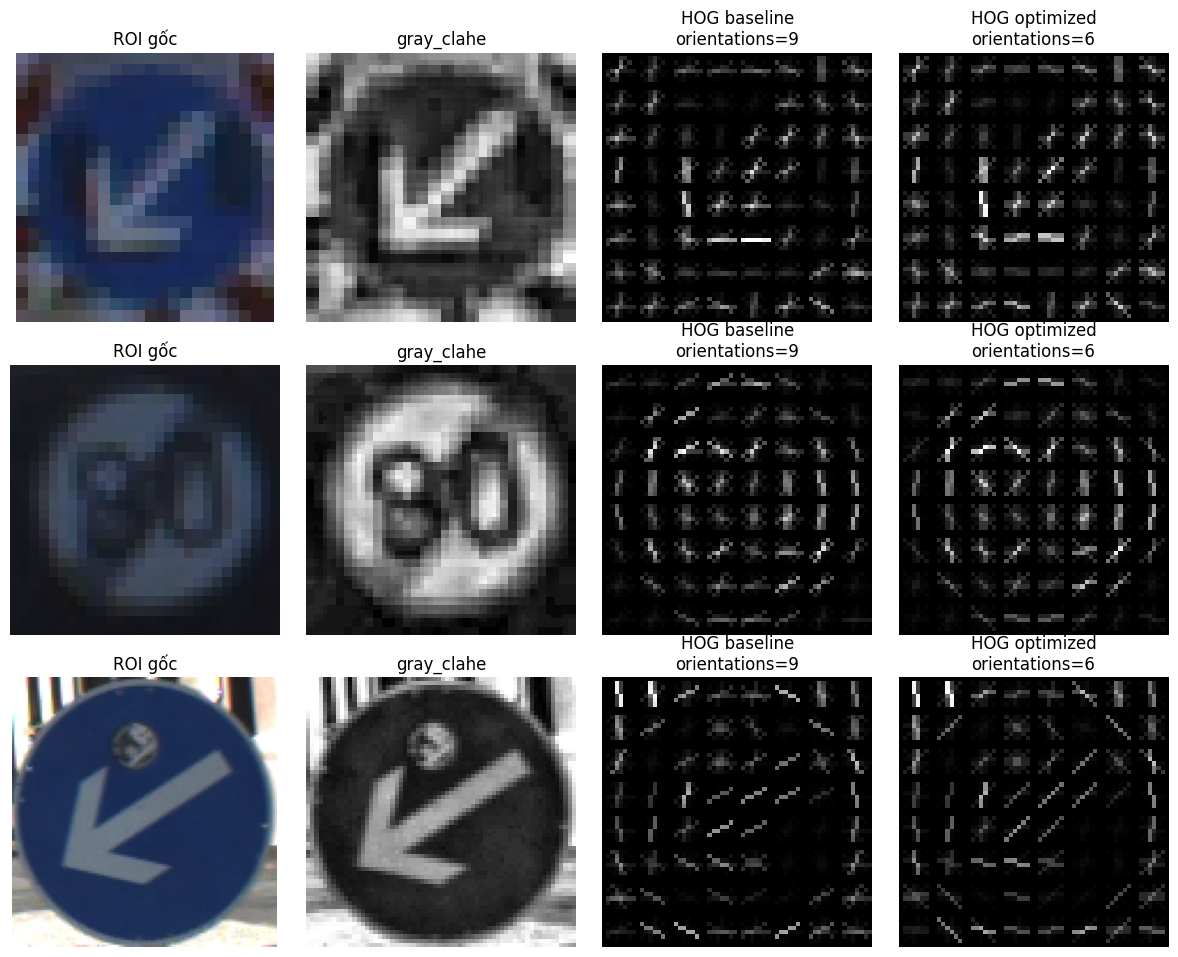

In [33]:
visual_test_df = df[df["filename"].isin(test_files)].reset_index(drop=True).copy()
visual_test_df["true_label"] = baseline_result["y_test"]
visual_test_df["baseline_pred"] = baseline_result["y_pred"]
visual_test_df["optimized_pred"] = optimized_result["y_pred"]

baseline_wrong_optimized_correct = visual_test_df[
    (visual_test_df["baseline_pred"] != visual_test_df["true_label"])
    & (visual_test_df["optimized_pred"] == visual_test_df["true_label"])
].copy()

selected_indices = []

mandatory_fixed = baseline_wrong_optimized_correct[baseline_wrong_optimized_correct["true_label"] == "mandatory"]
if len(mandatory_fixed) > 0:
    selected_indices.extend(mandatory_fixed.index.tolist()[:1])

for idx in baseline_wrong_optimized_correct.index:
    if idx not in selected_indices:
        selected_indices.append(idx)
    if len(selected_indices) >= 3:
        break

if len(selected_indices) < 3:
    for label in ["mandatory"] + GROUP_ORDER:
        candidates = visual_test_df[visual_test_df["true_label"] == label]
        for idx in candidates.index:
            if idx not in selected_indices:
                selected_indices.append(idx)
                break
        if len(selected_indices) >= 3:
            break

if len(selected_indices) < 3:
    for idx in visual_test_df.index:
        if idx not in selected_indices:
            selected_indices.append(idx)
        if len(selected_indices) >= 3:
            break

selected_samples = visual_test_df.loc[selected_indices[:3]].copy()
display(selected_samples[["filename", "class_id", "true_label", "baseline_pred", "optimized_pred"]])


def normalize_for_display(image):
    image = image.astype(np.float32)
    lo, hi = image.min(), image.max()
    if hi - lo < 1e-8:
        return np.zeros_like(image)
    return (image - lo) / (hi - lo)


def hog_visualization(image_rgb, config):
    hog_input = preprocess_for_hog(
        image_rgb,
        image_size=normalize_tuple(config["image_size"]),
        preprocessing=config["preprocessing"],
    )
    _, hog_image = hog(
        hog_input,
        orientations=int(config["orientations"]),
        pixels_per_cell=normalize_tuple(config["pixels_per_cell"]),
        cells_per_block=normalize_tuple(config["cells_per_block"]),
        block_norm=config["block_norm"],
        visualize=True,
        feature_vector=True,
    )
    return hog_input, normalize_for_display(hog_image)


baseline_visual_config = make_hog_config(**DEFAULT_HOG_CONFIG)
optimized_visual_config = make_hog_config(**optimized_config)

fig, axes = plt.subplots(len(selected_samples), 4, figsize=(12, 3.2 * len(selected_samples)))
if len(selected_samples) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(selected_samples.iterrows()):
    image = read_image(DATA_ROOT / row["filename"])
    crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
    baseline_preprocessed, baseline_hog_vis = hog_visualization(crop, baseline_visual_config)
    _, optimized_hog_vis = hog_visualization(crop, optimized_visual_config)

    axes[row_idx, 0].imshow(crop)
    axes[row_idx, 0].set_title("ROI gốc")
    axes[row_idx, 1].imshow(baseline_preprocessed, cmap="gray")
    axes[row_idx, 1].set_title("gray_clahe")
    axes[row_idx, 2].imshow(baseline_hog_vis, cmap="gray")
    axes[row_idx, 2].set_title("HOG baseline\norientations=9")
    axes[row_idx, 3].imshow(optimized_hog_vis, cmap="gray")
    axes[row_idx, 3].set_title("HOG optimized\norientations=6")

    caption = (
        f"true_label={row['true_label']}\n"
        f"baseline_pred={row['baseline_pred']}\n"
        f"optimized_pred={row['optimized_pred']}"
    )
    axes[row_idx, 0].set_ylabel(caption, fontsize=9)
    for col in range(4):
        axes[row_idx, col].axis("off")

plt.tight_layout()
plt.show()


In [34]:
_, _, baseline_visual_f1, _ = precision_recall_fscore_support(
    baseline_result["y_test"],
    baseline_result["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)
_, _, optimized_visual_f1, _ = precision_recall_fscore_support(
    optimized_result["y_test"],
    optimized_result["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)

visual_per_class_delta = pd.DataFrame({
    "class": GROUP_ORDER,
    "baseline_f1": baseline_visual_f1,
    "optimized_f1": optimized_visual_f1,
})
visual_per_class_delta["delta_f1"] = visual_per_class_delta["optimized_f1"] - visual_per_class_delta["baseline_f1"]
display(visual_per_class_delta)

mandatory_row = visual_per_class_delta[visual_per_class_delta["class"] == "mandatory"]
if len(mandatory_row) > 0:
    mandatory_delta = mandatory_row["delta_f1"].iloc[0]
    print(f"Trong split hiện tại, lớp mandatory có delta F1 = {mandatory_delta:+.4f} khi dùng optimized HOG.")
    if mandatory_delta > 0:
        print("Lớp mandatory cải thiện rõ hơn khi dùng optimized HOG, nên các ví dụ mandatory là minh họa phù hợp cho sự thay đổi biểu diễn HOG.")


,class,baseline_f1,optimized_f1,delta_f1
0,prohibitory,0.989474,0.992958,0.003484
1,danger,1.000000,1.000000,0.000000
2,mandatory,0.920635,0.952381,0.031746
3,other,0.969697,0.977444,0.007747


Trong split hiện tại, lớp mandatory có delta F1 = +0.0317 khi dùng optimized HOG.
Lớp mandatory cải thiện rõ hơn khi dùng optimized HOG, nên các ví dụ mandatory là minh họa phù hợp cho sự thay đổi biểu diễn HOG.


Các hình HOG visualization không dùng để chứng minh tuyệt đối rằng `orientations=6` luôn tốt hơn `orientations=9`. Chúng dùng để minh họa sự khác biệt trong cách hai cấu hình biểu diễn cạnh/gradient. Kết luận chính vẫn dựa trên Macro F1 ở thí nghiệm chính và robustness benchmark.


## 12. Phân tích độ bền và lỗi sai của mô hình

Phần này không nhằm thay đổi bài toán sang tìm bounding box trên ảnh gốc, mà nhằm kiểm tra xem cấu hình HOG tối ưu có thật sự bền hơn trong các điều kiện ảnh khó hơn hay không. Vì HOG phụ thuộc vào gradient, các biến đổi như brightness, contrast, blur và noise có thể làm thay đổi vector HOG. Do đó robustness benchmark giúp đánh giá sâu hơn so với chỉ đo Macro F1 trên test sạch.

Các biến đổi được áp dụng trực tiếp lên ROI của test set và giữ nguyên label gốc. Không dùng các biến thể crop để voting, không sinh vùng ứng viên và không đánh giá bước tìm bounding box.


In [35]:
def transform_identity(image_rgb, idx=None):
    return image_rgb


def transform_low_brightness(image_rgb, idx=None):
    return np.clip(image_rgb.astype(np.float32) * 0.65, 0, 255).astype(np.uint8)


def transform_high_brightness(image_rgb, idx=None):
    return np.clip(image_rgb.astype(np.float32) * 1.25 + 10, 0, 255).astype(np.uint8)


def transform_low_contrast(image_rgb, idx=None):
    mean = np.array([127.5], dtype=np.float32)
    return np.clip((image_rgb.astype(np.float32) - mean) * 0.65 + mean, 0, 255).astype(np.uint8)


def transform_gaussian_blur(image_rgb, idx=None):
    return cv2.GaussianBlur(image_rgb, (5, 5), 0)


def make_gaussian_noise_transform(seed=RANDOM_STATE, sigma=8.0):
    def _transform(image_rgb, idx=None):
        local_seed = seed if idx is None else seed + int(idx)
        rng = np.random.default_rng(local_seed)
        noise = rng.normal(0, sigma, image_rgb.shape)
        return np.clip(image_rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return _transform


ROBUSTNESS_TRANSFORMS = {
    "clean": transform_identity,
    "low_brightness": transform_low_brightness,
    "high_brightness": transform_high_brightness,
    "low_contrast": transform_low_contrast,
    "gaussian_blur": transform_gaussian_blur,
    "gaussian_noise": make_gaussian_noise_transform(),
}


def build_transformed_test_features(config, transform_fn, include_color=False, color_bins=16):
    X, y_true = [], []
    test_df = df[df["filename"].isin(test_files)].reset_index(drop=True)
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Robustness features"):
        image = read_image(DATA_ROOT / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if crop.size == 0:
            continue
        transformed = transform_fn(crop, idx=idx)
        X.append(extract_feature_from_crop(transformed, config, include_color=include_color, color_bins=color_bins))
        y_true.append(row["label_group"])
    return np.vstack(X), np.array(y_true)


def evaluate_model_under_transform(model_name, clf, config, transform_name, transform_fn, include_color=False):
    X_test_transformed, y_true = build_transformed_test_features(config, transform_fn, include_color=include_color)
    y_pred = clf.predict(X_test_transformed)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "model": model_name,
        "condition": transform_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


robustness_model_specs = [
    {
        "model": "Baseline HOG + SVM",
        "classifier": baseline_result["classifier"],
        "config": DEFAULT_HOG_CONFIG,
        "include_color": False,
    },
    {
        "model": "Optimized HOG + SVM",
        "classifier": optimized_result["classifier"],
        "config": optimized_config,
        "include_color": False,
    },
    {
        "model": "Color + HOG + SVM",
        "classifier": color_hog_result["classifier"],
        "config": DEFAULT_HOG_CONFIG,
        "include_color": True,
    },
]

robustness_rows = []
robustness_predictions = {}
for spec in robustness_model_specs:
    for condition, transform_fn in ROBUSTNESS_TRANSFORMS.items():
        result = evaluate_model_under_transform(
            spec["model"],
            spec["classifier"],
            spec["config"],
            condition,
            transform_fn,
            include_color=spec["include_color"],
        )
        robustness_predictions[(spec["model"], condition)] = {
            "y_true": result.pop("y_true"),
            "y_pred": result.pop("y_pred"),
        }
        robustness_rows.append(result)

robustness_results = pd.DataFrame(robustness_rows)
display(robustness_results[["model", "condition", "accuracy", "macro_precision", "macro_recall", "macro_f1"]])


Robustness features: 100%|██████████| 306/306 [00:01<00:00, 181.87it/s]


,model,condition,accuracy,macro_precision,macro_recall,macro_f1
0,Baseline HOG + SVM,clean,0.980392,0.978883,0.962121,0.969951
1,Baseline HOG + SVM,low_brightness,0.973856,0.964299,0.962363,0.963314
2,Baseline HOG + SVM,high_brightness,0.967320,0.953588,0.954787,0.954079
3,Baseline HOG + SVM,low_contrast,0.983660,0.975039,0.969697,0.972310
4,Baseline HOG + SVM,gaussian_blur,0.967320,0.952784,0.948985,0.950730
5,Baseline HOG + SVM,gaussian_noise,0.888889,0.862613,0.910461,0.879899
6,Optimized HOG + SVM,clean,0.986928,0.989041,0.973485,0.980696
7,Optimized HOG + SVM,low_brightness,0.980392,0.975260,0.965909,0.970445
8,Optimized HOG + SVM,high_brightness,0.983660,0.985449,0.971712,0.977982
9,Optimized HOG + SVM,low_contrast,0.986928,0.989041,0.973485,0.980696


,model,clean_macro_f1,avg_robust_macro_f1,worst_case_macro_f1,drop_from_clean
2,Optimized HOG + SVM,0.980696,0.951650,0.868706,0.029046
1,Color + HOG + SVM,0.975039,0.946094,0.870231,0.028945
0,Baseline HOG + SVM,0.969951,0.944066,0.879899,0.025885


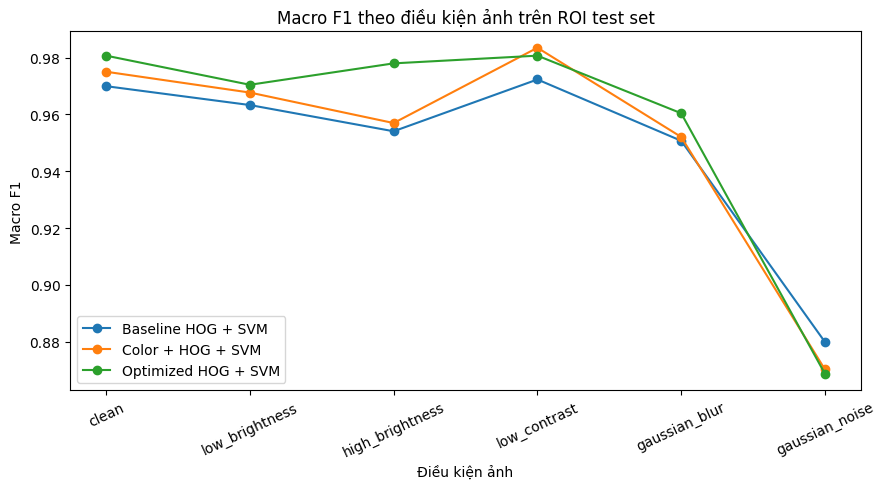

Model tốt nhất trên test sạch là Optimized HOG + SVM.
Model bền nhất trung bình trên các điều kiện ảnh xấu là Optimized HOG + SVM.
Model tốt nhất trên ảnh sạch cũng là model bền nhất trong robustness benchmark hiện tại.


In [36]:
robustness_summary_rows = []
for model_name, group in robustness_results.groupby("model"):
    clean_macro_f1 = group.loc[group["condition"] == "clean", "macro_f1"].iloc[0]
    non_clean = group[group["condition"] != "clean"]
    avg_robust_macro_f1 = non_clean["macro_f1"].mean()
    worst_case_macro_f1 = non_clean["macro_f1"].min()
    robustness_summary_rows.append({
        "model": model_name,
        "clean_macro_f1": clean_macro_f1,
        "avg_robust_macro_f1": avg_robust_macro_f1,
        "worst_case_macro_f1": worst_case_macro_f1,
        "drop_from_clean": clean_macro_f1 - avg_robust_macro_f1,
    })

robustness_summary = pd.DataFrame(robustness_summary_rows).sort_values("avg_robust_macro_f1", ascending=False)
display(robustness_summary)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, group in robustness_results.groupby("model"):
    ordered = group.set_index("condition").loc[list(ROBUSTNESS_TRANSFORMS.keys())].reset_index()
    ax.plot(ordered["condition"], ordered["macro_f1"], marker="o", label=model_name)
ax.set_title("Macro F1 theo điều kiện ảnh trên ROI test set")
ax.set_xlabel("Điều kiện ảnh")
ax.set_ylabel("Macro F1")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

best_clean = robustness_summary.sort_values("clean_macro_f1", ascending=False).iloc[0]
best_robust = robustness_summary.sort_values("avg_robust_macro_f1", ascending=False).iloc[0]

print(f"Model tốt nhất trên test sạch là {best_clean['model']}.")
print(f"Model bền nhất trung bình trên các điều kiện ảnh xấu là {best_robust['model']}.")

if best_clean["model"] != best_robust["model"]:
    print("Model tốt nhất trên ảnh sạch không nhất thiết là model bền nhất khi điều kiện ảnh thay đổi.")
else:
    print("Model tốt nhất trên ảnh sạch cũng là model bền nhất trong robustness benchmark hiện tại.")


### Failure analysis trên test sạch

Phần này so sánh lỗi giữa baseline HOG + SVM và Optimized HOG + SVM trên test set sạch. Mục tiêu là xem tối ưu HOG cải thiện lớp nào và có tạo thêm lỗi mới ở lớp nào hay không.


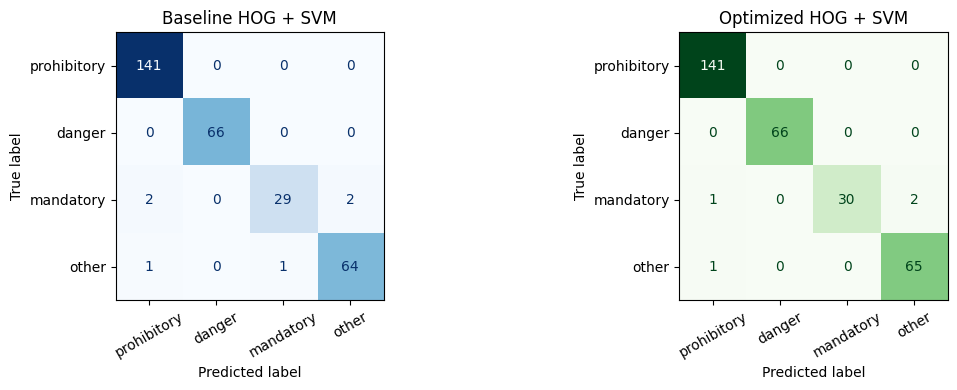

,class,baseline_f1,optimized_f1
0,prohibitory,0.989474,0.992958
1,danger,1.000000,1.000000
2,mandatory,0.920635,0.952381
3,other,0.969697,0.977444


,class,baseline_f1,optimized_f1,delta_f1
0,prohibitory,0.989474,0.992958,0.003484
1,danger,1.000000,1.000000,0.000000
2,mandatory,0.920635,0.952381,0.031746
3,other,0.969697,0.977444,0.007747


In [37]:
baseline_clean_pred = robustness_predictions[("Baseline HOG + SVM", "clean")]
optimized_clean_pred = robustness_predictions[("Optimized HOG + SVM", "clean")]

baseline_cm = confusion_matrix(baseline_clean_pred["y_true"], baseline_clean_pred["y_pred"], labels=GROUP_ORDER)
optimized_cm = confusion_matrix(optimized_clean_pred["y_true"], optimized_clean_pred["y_pred"], labels=GROUP_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(baseline_cm, display_labels=GROUP_ORDER).plot(ax=axes[0], cmap="Blues", xticks_rotation=30, colorbar=False)
axes[0].set_title("Baseline HOG + SVM")
ConfusionMatrixDisplay(optimized_cm, display_labels=GROUP_ORDER).plot(ax=axes[1], cmap="Greens", xticks_rotation=30, colorbar=False)
axes[1].set_title("Optimized HOG + SVM")
plt.tight_layout()
plt.show()

_, _, baseline_per_class_f1, _ = precision_recall_fscore_support(
    baseline_clean_pred["y_true"],
    baseline_clean_pred["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)
_, _, optimized_per_class_f1, _ = precision_recall_fscore_support(
    optimized_clean_pred["y_true"],
    optimized_clean_pred["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)

per_class_f1 = pd.DataFrame({
    "class": GROUP_ORDER,
    "baseline_f1": baseline_per_class_f1,
    "optimized_f1": optimized_per_class_f1,
})
per_class_delta = per_class_f1.copy()
per_class_delta["delta_f1"] = per_class_delta["optimized_f1"] - per_class_delta["baseline_f1"]

display(per_class_f1)
display(per_class_delta[["class", "baseline_f1", "optimized_f1", "delta_f1"]])


,filename,class_id,y_true,baseline_pred,optimized_pred
141,00352.ppm,6,other,mandatory,other
262,00725.ppm,39,mandatory,prohibitory,mandatory


,filename,class_id,y_true,baseline_pred,optimized_pred


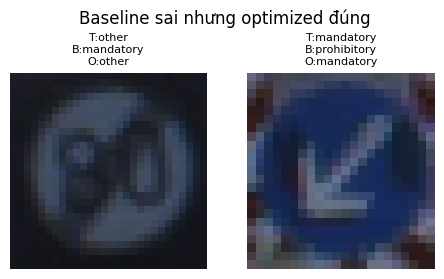

Baseline đúng nhưng optimized sai: không có ví dụ.


In [38]:
test_df_for_errors = df[df["filename"].isin(test_files)].reset_index(drop=True).copy()
test_df_for_errors["y_true"] = baseline_clean_pred["y_true"]
test_df_for_errors["baseline_pred"] = baseline_clean_pred["y_pred"]
test_df_for_errors["optimized_pred"] = optimized_clean_pred["y_pred"]

baseline_wrong_optimized_correct = test_df_for_errors[
    (test_df_for_errors["baseline_pred"] != test_df_for_errors["y_true"])
    & (test_df_for_errors["optimized_pred"] == test_df_for_errors["y_true"])
]
baseline_correct_optimized_wrong = test_df_for_errors[
    (test_df_for_errors["baseline_pred"] == test_df_for_errors["y_true"])
    & (test_df_for_errors["optimized_pred"] != test_df_for_errors["y_true"])
]

display(baseline_wrong_optimized_correct[["filename", "class_id", "y_true", "baseline_pred", "optimized_pred"]].head(10))
display(baseline_correct_optimized_wrong[["filename", "class_id", "y_true", "baseline_pred", "optimized_pred"]].head(10))


def show_error_examples(example_df, title, max_examples=6):
    if example_df.empty:
        print(f"{title}: không có ví dụ.")
        return
    n = min(max_examples, len(example_df))
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.8))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, example_df.head(n).iterrows()):
        image = read_image(DATA_ROOT / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        ax.imshow(crop)
        ax.set_title(f"T:{row['y_true']}\nB:{row['baseline_pred']}\nO:{row['optimized_pred']}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_error_examples(baseline_wrong_optimized_correct, "Baseline sai nhưng optimized đúng")
show_error_examples(baseline_correct_optimized_wrong, "Baseline đúng nhưng optimized sai")


## 13. Nhận xét kết quả và hạn chế

Kết luận cuối không chỉ dựa trên Macro F1 ở test sạch, mà còn xét thêm robustness benchmark trên các ROI bị thay đổi brightness, contrast, blur và noise. Notebook vẫn giữ phạm vi classification trên ROI crop từ ground-truth bounding box.


In [39]:
best_robust_model = robustness_summary.sort_values("avg_robust_macro_f1", ascending=False).iloc[0]

print("Kết quả chính trên test sạch:")
print(f"- Baseline HOG + SVM mặc định đạt Macro F1 = {baseline_result['macro_f1']:.4f}.")
print(f"- Optimized HOG + SVM đạt Macro F1 = {optimized_result['macro_f1']:.4f}.")
print(f"- Delta = {delta_optimized:+.4f} Macro F1.")

if delta_optimized > 0:
    print("- Tối ưu tham số HOG cải thiện Macro F1 so với baseline HOG + SVM mặc định.")
else:
    print("- Tối ưu tham số HOG chưa cải thiện Macro F1 trong split hiện tại.")

print("\nKết quả robustness:")
print(f"- Model bền nhất theo avg_robust_macro_f1 là {best_robust_model['model']} với avg_robust_macro_f1 = {best_robust_model['avg_robust_macro_f1']:.4f}.")
optimized_robust_row = robustness_summary[robustness_summary["model"] == "Optimized HOG + SVM"].iloc[0]
print(f"- Optimized HOG + SVM có drop_from_clean = {optimized_robust_row['drop_from_clean']:.4f}.")

if optimized_robust_row["drop_from_clean"] > robustness_summary["drop_from_clean"].median():
    print("- Optimized HOG tốt trên test sạch nhưng giảm tương đối nhiều khi ảnh bị biến đổi; cần trình bày trung thực trade-off này.")
else:
    print("- Optimized HOG duy trì độ bền tương đối tốt trong robustness benchmark hiện tại.")

color_robust_row = robustness_summary[robustness_summary["model"] == "Color + HOG + SVM"].iloc[0]
if color_robust_row["avg_robust_macro_f1"] > optimized_robust_row["avg_robust_macro_f1"]:
    print("- Color + HOG bền hơn trung bình trong các điều kiện ảnh xấu; đây là vai trò phụ của thông tin màu, nhưng không đổi hướng chính của bài.")
else:
    print("- Color + HOG không bền hơn optimized HOG trung bình trong robustness benchmark hiện tại.")

print("\nKết quả phụ:")
print(f"- Color + HOG có delta = {color_delta:+.4f} Macro F1 so với baseline trên test sạch.")
if abs(color_delta) < 0.005:
    print("- Mức thay đổi của Color + HOG rất nhỏ, không đủ để xem là cải tiến chính.")
elif color_delta > 0:
    print("- Color + HOG có cải thiện nhưng không phải hướng chính của notebook.")
else:
    print("- Color + HOG không cải thiện trong thiết lập hiện tại.")

print("\nHạn chế:")
print("- Bài toán hiện tại chỉ đánh giá classification trên ROI crop từ ground-truth bounding box.")
print("- Kết quả phụ thuộc vào cách chia train/test theo ảnh.")
print("- Các sweep chỉ thử một số giá trị đại diện, chưa phải tìm kiếm toàn bộ không gian tham số.")
print("- Notebook chưa đánh giá khả năng phát hiện bounding box trên ảnh gốc vì phạm vi bài chỉ tập trung vào classification.")


Kết quả chính trên test sạch:
- Baseline HOG + SVM mặc định đạt Macro F1 = 0.9700.
- Optimized HOG + SVM đạt Macro F1 = 0.9807.
- Delta = +0.0107 Macro F1.
- Tối ưu tham số HOG cải thiện Macro F1 so với baseline HOG + SVM mặc định.

Kết quả robustness:
- Model bền nhất theo avg_robust_macro_f1 là Optimized HOG + SVM với avg_robust_macro_f1 = 0.9516.
- Optimized HOG + SVM có drop_from_clean = 0.0290.
- Optimized HOG tốt trên test sạch nhưng giảm tương đối nhiều khi ảnh bị biến đổi; cần trình bày trung thực trade-off này.
- Color + HOG không bền hơn optimized HOG trung bình trong robustness benchmark hiện tại.

Kết quả phụ:
- Color + HOG có delta = +0.0051 Macro F1 so với baseline trên test sạch.
- Color + HOG có cải thiện nhưng không phải hướng chính của notebook.

Hạn chế:
- Bài toán hiện tại chỉ đánh giá classification trên ROI crop từ ground-truth bounding box.
- Kết quả phụ thuộc vào cách chia train/test theo ảnh.
- Các sweep chỉ thử một số giá trị đại diện, chưa phải tìm kiếm toàn 